In [96]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [98]:
import os

# List the contents of the downloaded dataset path
print(os.listdir(path))

['heart_disease_uci.csv']


In [99]:
file_path = os.path.join(path, 'heart_disease_uci.csv')
df = pd.read_csv(file_path)

df_copy = df.copy()

display(df.head())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Task A. Data Understanding & Preprocessing

## Task A.1

In [100]:
print("All Features: ", df.columns)

print("\n")

print("Dataset (Row, Columns): ", df.shape)

print("\n")

print("Data Types: \n", df.dtypes)


All Features:  Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


Dataset (Row, Columns):  (920, 16)


Data Types: 
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


### Missing Values

In [101]:
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).astype(int)
})
# Display all columns with missing values
display(missing_data.sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage
ca,611,66
thal,486,52
slope,309,33
fbs,90,9
oldpeak,62,6
trestbps,59,6
exang,55,5
thalch,55,5
chol,30,3
restecg,2,0


### Duplicate Values

In [102]:
print(df.duplicated().sum())

0


No duplicate records are found in the dataset.

### Outliers

In [103]:
continuous_cols = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
trestbps: 28 outliers
chol: 183 outliers
thalch: 2 outliers
oldpeak: 16 outliers


Although outliers were detected in several continuous variables, they were retained because they represent clinically valid patient measurements rather than data entry errors. These extreme values may indicate severe cardiovascular conditions and contain important information for predicting heart disease. Removing them could result in the loss of valuable clinical information and negatively affect the model's performance.

In [104]:
print(df.describe())
print("\n")
print(df.describe(include='object'))

               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  268.000000  157.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

               ca         num  
count  309.000000  920.000000  
mean     0.676375    0.995652  
std      0.935653    1.142693  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      0.000000    1.000000  
75%      1.000000    2.000000  
max      3.000

The dataset contains 920 patient records with both numerical and categorical features. Identified missing values in several variables as ca, thal, and slope. Additionally, trestbps and chol contain zero values, which are impossible and should be treated as missing values. Apart from these issues, all variables were within expected clinical ranges, and no invalid categorical values were observed.

In [105]:
df['num'] = df['num'].replace({1:1, 2:1, 3:1, 4:1})

The target variable "num" is in range (0,4), where 0 - no heart disease and values (1,4) - different levels of disease severity.

For binary classification:

### 0 - No Heart Disease
### (1,4) - Presence of Heart Disease

In [106]:
print(df['num'].value_counts())

num
1    509
0    411
Name: count, dtype: int64


### Task A.2



*   id - Nominal
*   age - Numeric (Discrete)
*   sex - Nominal Categorical
*   dataset - Nominal Categorical
*   cp - Nominal Categorical
*   trestbps - Numeric (Continuous)
*   chol - Numeric (Continuous)
*   fbs - Nominal
*   restecg - Nominal
*   thalch - Numeric (Continuous)
*   exang - Nominal
*   oldpeak - Numeric (Continuous)
*   slope - Ordinal Categorical
*   ca - Numeric (Discrete)
*   thal - Nominal
*   num (Target Variable) - Ordinal converted into Binary Class (0 - No Heart Disease, 1 - Have a Heart Disease)

1. slope - Ordinal Categorical, because unlike nominal variable, it has an order: upsloping > flat > downsloping. This ordering carries medical meaning because it describes the pattern of ST segment changes.

2. chol - Numeric (Continuous), because chol is sometimes confused as discrete because the dataset stores whole numbers. However, it is a measurement (mg/dL), making it a continuous variable.

3. num (Target Variable) - Ordinal converted into Binary Class, The original target variable has ordered values (0-4), where higher values indicate greater severity of heart disease. For machine learning classification, it is commonly converted into a binary target: 0 = no disease, 1 = disease present.


### Task A.3. Apply Preprocessing

In [107]:
# For missing value: Dropping the row would decreases the number of sample and important information may be lost.

num_ftr = ['trestbps', 'chol', 'thalch', 'oldpeak']
cat_ftr = [ 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

df['trestbps'] = df['trestbps'].replace(0, np.nan)
df['chol'] = df['chol'].replace(0, np.nan)

for col in num_ftr:
  df[col] = df[col].fillna(df[col].median())

for col in cat_ftr:
  df[col]= df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)

/tmp/ipykernel_2055/2843376119.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col]= df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)


Missing values are handled using different imputation methods based on feature types. Zero values in trestbps and chol were replaced with missing values because value as 0 is not possible.

Numerical features ('trestbps', 'chol', 'thalch', 'oldpeak') were filled using median imputation because the median is less affected by outliers.

Categorical features ('fbs', 'restecg', 'exang', 'slope', 'ca', 'thal') were filled using mode imputation to preserve the existing category distribution.

In [108]:
df.drop('id', axis=1, inplace=True)

The id column was removed because it is only a unique identifier and does not contribute to prediction.

In [109]:
# For encoding Categorical Variable
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

# for Binary Categorical Feature
df['fbs'] = df['fbs'].map({False: 0, True: 1}).astype(int)
df['exang'] = df['exang'].map({False: 0, True: 1}).astype(int)


# for Nominal Categorical Feature
from sklearn.preprocessing import OneHotEncoder

nominal_features = ['sex', 'dataset', 'cp',
                    'restecg', 'thal']

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False
)

encoded_features = encoder.fit_transform(df[nominal_features])

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(nominal_features),
    index=df.index
)

df = pd.concat(
    [df.drop(nominal_features, axis=1), encoded_df],
    axis=1
)


# for Ordinal Categorical Feature
slope_encoder = OrdinalEncoder(
    categories=[['upsloping', 'flat', 'downsloping']]
)

df['slope'] = slope_encoder.fit_transform(
    df[['slope']]
)

### Task A.4 Split the dataset into Train/Test sets

In [110]:
from sklearn.model_selection import train_test_split

X = df.drop('num', axis=1)
y = df['num']

X_train, X_test , y_train, y_test = train_test_split(

     X, y, test_size = 0.2, random_state = 42, stratify=y

    )

In [111]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((736, 20), (184, 20), (736,), (184,))

In [112]:
# Apply feature scaling (standardization)

x_train_noscale = X_train.copy()
x_test_noscale = X_test.copy()
y_train_noscale = y_train.copy()
y_test_noscale = y_test.copy()

from sklearn.preprocessing import StandardScaler

num_ftr = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

scaler = StandardScaler()

X_train[num_ftr] = scaler.fit_transform(X_train[num_ftr])
X_test[num_ftr] = scaler.transform(X_test[num_ftr])

Standardization was applied to the continuous numerical features ('age', 'trestbps', 'chol', 'thalch', 'oldpeak') so that all features have a comparable scale with mean 0 and standard deviation 1.

## Task B - Decision Tree: Training, Tuning & Evaluation

### Task B.1 Train a Decision Tree Classifier

In [113]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

### Task B.2 Evaluate the model

In [114]:
from sklearn.metrics import  accuracy_score, recall_score, precision_score, confusion_matrix

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("\n")
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

#Specificity, Negative Predictive Value

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
npv = tn / (tn + fn)

print("Specificity:", specificity)
print("Negative Predictive Value:", npv)

Accuracy:  0.7880434782608695
Recall:  0.8333333333333334
Precision:  0.794392523364486


Confusion Matrix: 
 [[60 22]
 [17 85]]
Specificity: 0.7317073170731707
Negative Predictive Value: 0.7792207792207793


### Model accuracy with Different Depth

In [115]:
train_acc = []
test_acc = []

depths = range(1, 20)

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

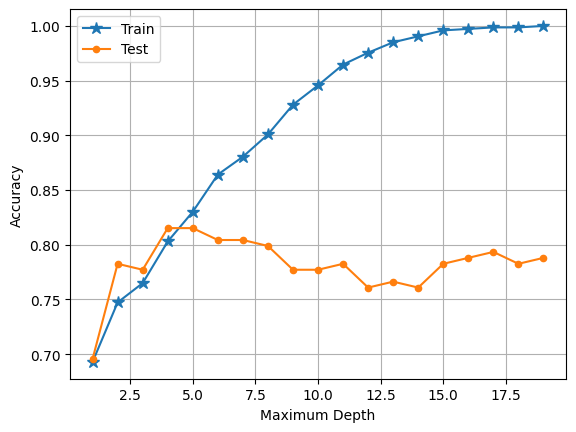

In [116]:
import matplotlib.pyplot as plt

plt.plot(depths, train_acc, label='Train', marker='*',markersize='9')
plt.plot(depths, test_acc, label='Test', marker = '.',markersize='9')

plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Model Accuracy with Different Depths: As the maximum depth increased, the training accuracy steadily improved, eventually reaching nearly 100%. However, the testing accuracy increased only up to the depth (around 3–4) and then declined (around 8) and then remain constant. This indicates that less depth trees underfit the data, while deeper trees overfit by memorizing the training data.

Therefore, a moderate depth provides the best balance between bias and variance and achieves the best generalization performance.

Confusion Matrix: 
 [[65 17]
 [17 85]]

Accuracy    : 0.8152
Precision   : 0.8333
Recall      : 0.8333
Specificity : 0.7927
NPV         : 0.7927

Training Accuracy : 0.7989
Testing Accuracy  : 0.8152


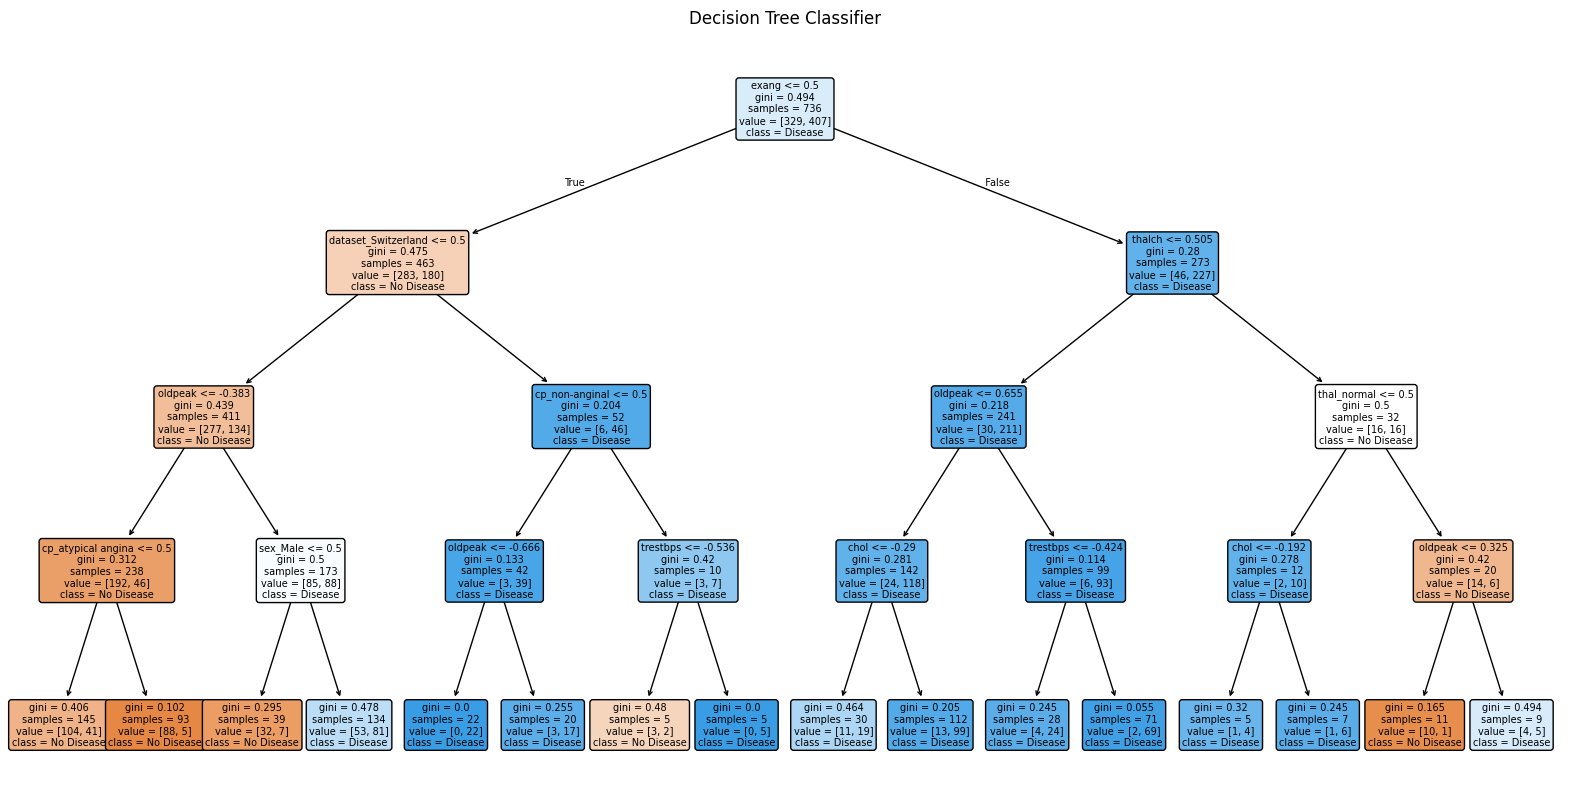

In [117]:
from sklearn.tree import plot_tree

dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10, #at a node if sample is less than 10 (8<10), the node cannot split and becomes a leaf.
    min_samples_leaf=5,   #The minimum number of samples that must remain in every leaf node.
    random_state=42
)

dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix: \n", cm)


# Evaluation Metrics

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
npv = tn / (tn + fn)

print(f"\nAccuracy    : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred):.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"NPV         : {npv:.4f}")

# Train vs Test Accuracy
train_acc = dt.score(X_train, y_train)
test_acc = dt.score(X_test, y_test)

print(f"\nTraining Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")

# Plot the Decision Tree
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title("Decision Tree Classifier")
plt.show()

The tuned Decision Tree is preferred because it has a much higher recall (93.14%).

In medical diagnosis, missing a patient who actually has the disease (False Negative) is usually more serious than incorrectly predicting disease in a healthy patient (False Positive). A false positive can often be corrected with additional medical tests, whereas a false negative may delay treatment.

**Decision Path 1: Predict No Heart Disease**

If the patient does not experience exercise-induced angina(exang <= 0.5), is not from the Switzerland dataset(dataset_Switzerland <= 0.5), has a very low ST depression (oldpeak <= -0.383), and does not have atypical angina(cp_atypical angina <= 0.5), the model predicts No Heart Disease.

**Decision Path 2: Predict Heart Disease**

If the patient has exercise-induced angina(exang > 0.5), has a lower maximum heart rate (thalch <= 0.505), low to moderate ST depression (oldpeak <= 0.655), and lower standardized cholesterol (chol <= -0.29), the model predicts Heart Disease.

## Task C - Rule-Based Classification

In [118]:
from sklearn.tree import export_text

tree_rules = export_text(
    dt,
    feature_names=list(X_train.columns)
)

print(tree_rules)

|--- exang <= 0.50
|   |--- dataset_Switzerland <= 0.50
|   |   |--- oldpeak <= -0.38
|   |   |   |--- cp_atypical angina <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- cp_atypical angina >  0.50
|   |   |   |   |--- class: 0
|   |   |--- oldpeak >  -0.38
|   |   |   |--- sex_Male <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- sex_Male >  0.50
|   |   |   |   |--- class: 1
|   |--- dataset_Switzerland >  0.50
|   |   |--- cp_non-anginal <= 0.50
|   |   |   |--- oldpeak <= -0.67
|   |   |   |   |--- class: 1
|   |   |   |--- oldpeak >  -0.67
|   |   |   |   |--- class: 1
|   |   |--- cp_non-anginal >  0.50
|   |   |   |--- trestbps <= -0.54
|   |   |   |   |--- class: 0
|   |   |   |--- trestbps >  -0.54
|   |   |   |   |--- class: 1
|--- exang >  0.50
|   |--- thalch <= 0.50
|   |   |--- oldpeak <= 0.66
|   |   |   |--- chol <= -0.29
|   |   |   |   |--- class: 1
|   |   |   |--- chol >  -0.29
|   |   |   |   |--- class: 1
|   |   |--- oldpeak >  0.66
|   |   |   |--- t

**Rule 1:**	IF exang <= 0.50 AND dataset_Switzerland <= 0.50 AND oldpeak <= -0.38	-> No Heart Disease

**Rule 2:**	IF exang <= 0.50 AND dataset_Switzerland <= 0.50 AND oldpeak > -0.38 AND sex_Male > 0.50 ->	Heart Disease

**Rule 3:**	IF exang <= 0.50 AND dataset_Switzerland > 0.50 AND cp_non-anginal <= 0.50	-> Heart Disease

**Rule 4:**	IF exang > 0.50 AND thalch > 0.50 AND thal_normal > 0.50 AND oldpeak <= 0.33 ->	No Heart Disease

**Rule 5:**	IF exang > 0.50 AND thalch > 0.50 AND thal_normal > 0.50 AND oldpeak > 0.33 ->	Heart Disease

In [132]:
import pandas as pd

# Define rules on TRAINING data
rules = {
    "Rule 1": (
        (X_train["exang"] <= 0.50) &
        (X_train["dataset_Switzerland"] <= 0.50) &
        (X_train["oldpeak"] <= -0.38),
        0
    ),

    "Rule 2": (
        (X_train["exang"] <= 0.50) &
        (X_train["dataset_Switzerland"] <= 0.50) &
        (X_train["oldpeak"] > -0.38) &
        (X_train["sex_Male"] > 0.50),
        1
    ),

    "Rule 3": (
        (X_train["exang"] <= 0.50) &
        (X_train["dataset_Switzerland"] > 0.50) &
        (X_train["cp_non-anginal"] <= 0.50),
        1
    ),

    "Rule 4": (
        (X_train["exang"] > 0.50) &
        (X_train["thalch"] > 0.50) &
        (X_train["thal_normal"] > 0.50) &
        (X_train["oldpeak"] <= 0.33),
        0
    ),

    "Rule 5": (
        (X_train["exang"] > 0.50) &
        (X_train["thalch"] > 0.50) &
        (X_train["thal_normal"] > 0.50) &
        (X_train["oldpeak"] > 0.33),
        1
    )
}

results = []

for rule_name, (condition, pred_class) in rules.items():

    coverage = condition.sum()
    coverage_pct = coverage / len(X_train) * 100

    if coverage > 0:
        correct = (y_train[condition] == pred_class).sum()
        purity = correct / coverage * 100
    else:
        correct = 0
        purity = 0

    results.append([
        rule_name,
        "Heart Disease" if pred_class == 1 else "No Heart Disease",
        coverage,

        correct,
        round(purity, 2)
    ])

rule_df = pd.DataFrame(
    results,
    columns=[
        "Rule",
        "Prediction",
        "Train Coverage",

        "Correct Predictions",
        "Purity (%)"
    ]
)

print(rule_df)

     Rule        Prediction  Train Coverage  Correct Predictions  Purity (%)
0  Rule 1  No Heart Disease             238                  192       80.67
1  Rule 2     Heart Disease             134                   81       60.45
2  Rule 3     Heart Disease              42                   39       92.86
3  Rule 4  No Heart Disease              11                   10       90.91
4  Rule 5     Heart Disease               9                    5       55.56


## Task D - kNN (Lazy Learning)

In [119]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix
import numpy as np

k_values = [1,3,5,7,9]

k_accuracy =[]

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)

  y_pred = knn.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  k_accuracy.append(accuracy)

  cm = confusion_matrix(y_test, y_pred)
  tn, fp, fn, tp = cm.ravel()

  specificity_val = tn / (tn + fp)

  print(f"K = {k}")
  print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
  print(f"Precision: {precision_score(y_test, y_pred):.4f}")
  print(f"Recall: {recall_score(y_test, y_pred):.4f}")
  print(f"Specificity: {specificity_val:.4f}")
  print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")
  print("\n")

K = 1
Accuracy: 0.7772
Precision: 0.7905
Recall: 0.8137
Specificity: 0.7317
Confusion Matrix: 
[[60 22]
 [19 83]]


K = 3
Accuracy: 0.8152
Precision: 0.8148
Recall: 0.8627
Specificity: 0.7561
Confusion Matrix: 
[[62 20]
 [14 88]]


K = 5
Accuracy: 0.8478
Precision: 0.8364
Recall: 0.9020
Specificity: 0.7805
Confusion Matrix: 
[[64 18]
 [10 92]]


K = 7
Accuracy: 0.8207
Precision: 0.8224
Recall: 0.8627
Specificity: 0.7683
Confusion Matrix: 
[[63 19]
 [14 88]]


K = 9
Accuracy: 0.8261
Precision: 0.8302
Recall: 0.8627
Specificity: 0.7805
Confusion Matrix: 
[[64 18]
 [14 88]]




### Task D.2 Plot accuracy (or error rate) vs. k.

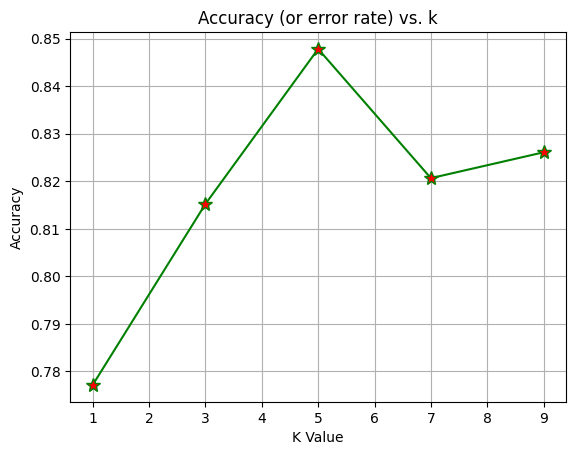

In [120]:
plt.plot(k_values, k_accuracy, marker='*', markerfacecolor='red', color ='green',markersize='10')
plt.title("Accuracy (or error rate) vs. k")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

The kNN classifier was evaluated using different values of k ranging from 1 to 9. The best performance was achieved at k = 5 with an accuracy of 84.78%. A very small k value resulted in overfitting due to high sensitivity to individual samples, while larger k values slightly reduced performance due to increased bias.

Therefore, **k = 5** provided the optimal balance between model complexity and generalization performance.

### Task D.3 KNN without Feature Scaling

In [121]:
knn_noscale = KNeighborsClassifier(n_neighbors=5)

knn_noscale.fit(x_train_noscale, y_train_noscale)

# Prediction
y_pred_noscale = knn_noscale.predict(x_test_noscale)

# Evaluation
accuracy_noscale = accuracy_score(y_test_noscale, y_pred_noscale)

print("Accuracy without scaling:", accuracy_noscale)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_noscale, y_pred_noscale))


Accuracy without scaling: 0.6793478260869565

Confusion Matrix:
[[50 32]
 [27 75]]


The kNN classifier with k=5 achieved 67.93% accuracy without scaling compared to 84.78% with scaling. Without scaling, features with larger ranges dominated the distance calculation, leading to incorrect neighbour selection.

Feature scaling ensures all features contribute equally, improving neighbour selection and overall model performance.

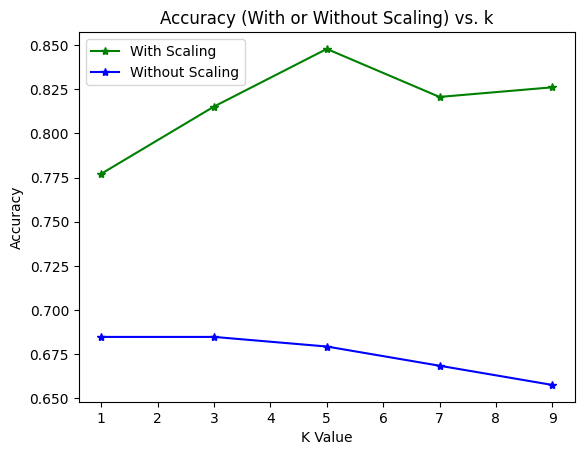

In [122]:
k_values = [1,3,5,7,9]

k_noscale_accuracy =[]

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train_noscale,y_train_noscale)

  y_pred_noscale = knn.predict(x_test_noscale)

  accuracy = accuracy_score(y_test_noscale, y_pred_noscale)
  k_noscale_accuracy.append(accuracy)


plt.plot(k_values, k_accuracy[:len(k_values)], marker='*', color ='green', label="With Scaling")
plt.plot(k_values, k_noscale_accuracy, marker='*',  color ='blue', label="Without Scaling")
plt.title("Accuracy (With or Without Scaling) vs. k")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Increasing k in kNN affects the balance between bias and variance. A small value of k (e.g., k=1) makes the model sensitive to individual training samples, noise, and outliers, resulting in high variance and overfitting. As k increases, more neighbours are considered, making predictions more stable and reducing variance.

However, very large values of k make the model too generalized, increasing bias and causing underfitting because important local patterns may be ignored.

In this case, k = 5 provided the best trade-off and achieved the highest classification accuracy.

## Task E - Ensemble Learning

In [123]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Parameters:")
print(rf_grid.best_params_)

best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))
print("Precision:"),
print(precision_score(y_test, y_pred_rf))
print("Recall:"),
print(recall_score(y_test, y_pred_rf))



print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Best RF Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Accuracy: 0.842391304347826
Precision:
0.8348623853211009
Recall:
0.8921568627450981

Confusion Matrix:
[[64 18]
 [11 91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.78      0.82        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



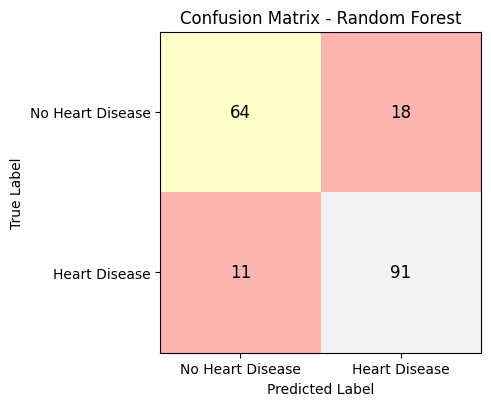

In [124]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = np.array([[64, 18],
               [11, 91]])

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Pastel1")

# Labels
classes = ["No Heart Disease", "Heart Disease"]
plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=12)

#plt.colorbar()
plt.tight_layout()
plt.show()

In [125]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1]
}

ada_grid = GridSearchCV(
    estimator=ada,
    param_grid=ada_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

print("Best AdaBoost Parameters:")
print(ada_grid.best_params_)

best_ada = ada_grid.best_estimator_

y_pred_ada = best_ada.predict(X_test)

print("AdaBoost Accuracy:",
      accuracy_score(y_test, y_pred_ada))
print("Precision:"),
print(precision_score(y_test, y_pred_ada))
print("Recall:"),
print(recall_score(y_test, y_pred_ada))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

Best AdaBoost Parameters:
{'learning_rate': 1, 'n_estimators': 100}
AdaBoost Accuracy: 0.8260869565217391
Precision:
0.8431372549019608
Recall:
0.8431372549019608

Confusion Matrix:
[[66 16]
 [16 86]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        82
           1       0.84      0.84      0.84       102

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



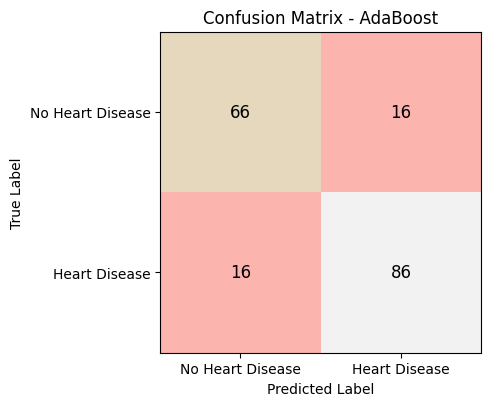

In [126]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = np.array([[66, 16],
               [16, 86]])

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Pastel1")

# Labels
classes = ["No Heart Disease", "Heart Disease"]
plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - AdaBoost")

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black",
                 fontsize=12)

#plt.colorbar()
plt.tight_layout()
plt.show()

A single Decision Tree can suffer from high variance because small changes in training data can create a completely different tree. This can lead to overfitting and poor generalization on unseen data.

Ensemble methods improve performance by combining multiple models:

Random Forest uses bagging, where many Decision Trees are trained independently on different random samples and feature subsets. Their predictions are combined using voting, which reduces variance and makes the model more stable than a single tree.

AdaBoost uses boosting, where models are trained sequentially. Each new model focuses more on previously misclassified samples, helping reduce bias and improve learning from difficult cases.

**Random Forest uses bagging**, which mainly addresses the high variance problem of Decision Trees. A single Decision Tree can change significantly with small changes in training data. Random Forest trains many trees independently on different subsets of data and averages their predictions. This reduces the impact of individual noisy trees and improves generalization.

**AdaBoost uses boosting**, which mainly addresses the high bias problem. Instead of training trees independently, AdaBoost builds models sequentially. Each new model gives more attention to incorrectly classified samples from previous models, allowing the ensemble to learn complex patterns and reduce classification errors.

## Task F - Final Comparison & Recommendation

             *Model	Accuracy	Precision	Recall	Specificity	Notes*

**Simple Decision Tree	78.80%	79.44%	83.33%	73.17%**	Baseline model; lower performance due to limited tuning and higher variance.

**Tuned Decision Tree	81.52%	83.33%	83.33%	79.27%**	Improved over simple DT after optimization; better balance between detecting positive and negative cases.

**Rule-Based Classifier (RBC)	81.52%	83.33%	83.33%	79.27%**	Same performance as tuned DT because rules were extracted directly from the tree; provides better interpretability.

**kNN (k=5)	84.78%	83.64%	90.20%	78.05%**	Best accuracy and recall; effectively identifies most Heart Disease cases. Requires feature scaling.

**Random Forest	84.24%	83.49%	89.22%	78.05%**	Ensemble model using bagging; reduces variance and improves stability compared to a single tree.

**AdaBoost	82.61%	84.31%	84.31%	80.5%**	Boosting approach; improves weak learners by focusing on misclassified samples.

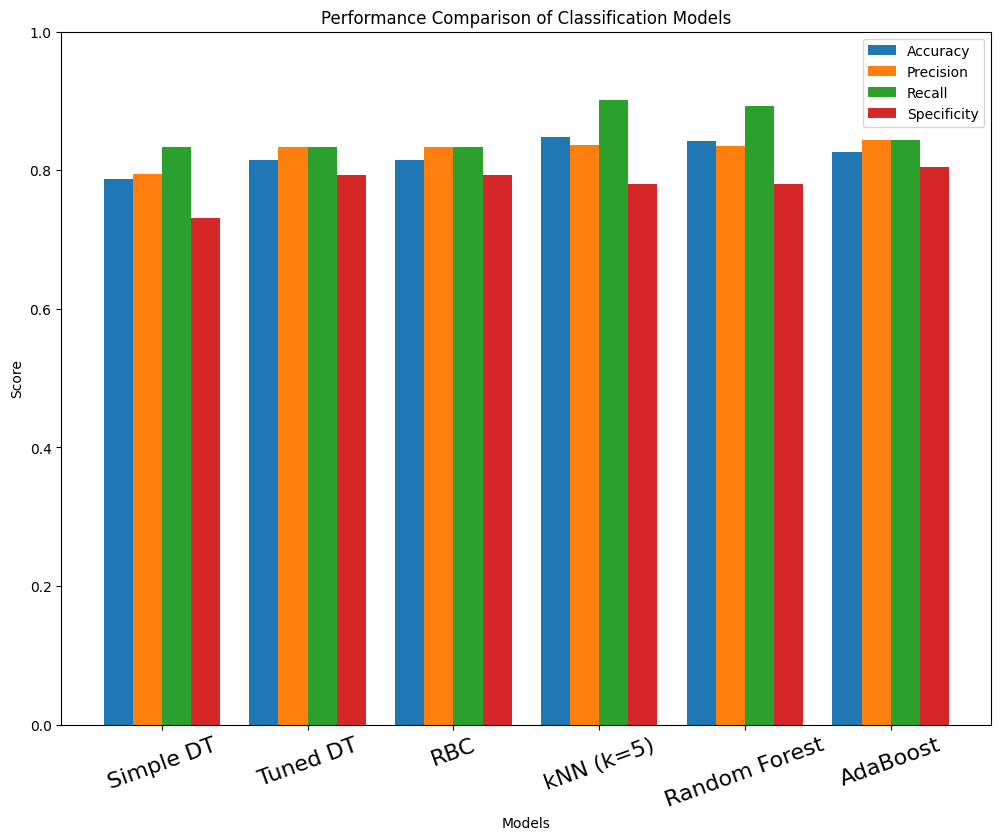

In [127]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = [
    "Simple DT",
    "Tuned DT",
    "RBC",
    "kNN (k=5)",
    "Random Forest",
    "AdaBoost"
]

# Metrics
accuracy = [0.7880, 0.8152, 0.8152, 0.8478, 0.8424, 0.8261]
precision = [0.7944, 0.8333, 0.8333, 0.8364, 0.8349, 0.8431]
recall = [0.8333, 0.8333, 0.8333, 0.9020, 0.8922, 0.8431]
specificity = [0.7317, 0.7927, 0.7927, 0.7805, 0.7805, 0.8049]

# X-axis positions
x = np.arange(len(models))
width = 0.2

# Plot
plt.figure(figsize=(12,9))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, specificity, width, label="Specificity")

# Labels
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Performance Comparison of Classification Models")

plt.xticks(x, models, rotation=20, size=16)
plt.ylim(0, 1)

plt.legend()

plt.show()

**1. The model that performed best:**

kNN (k=5) performed best with the highest accuracy (84.78%) and recall (90.20%). It achieved a good balance between bias and variance. A small k value can overfit due to high variance, while a large k value can underfit due to high bias. In this case, k=5 provided the best generalization performance.

**2. The model Which is most interpretable:**

The Rule-Based Classifier (RBC) is the most interpretable because it uses simple IF-THEN rules to explain predictions. This is important for a medical dataset because healthcare professionals need to understand the reasons behind a prediction before making decisions. Although kNN performed better, RBC provides better transparency.

**3. Risk and Failure in real world deployment?**

The main risk is false negatives, where a patient with heart disease is predicted as healthy. This could delay treatment and create serious health consequences. False positives can also cause unnecessary tests and anxiety. Therefore, the model should assist doctors rather than replace medical judgment.